In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("./data/birthday_paradox_sample.csv")
df

,trial,group_size,birthdays,shared_birthday,shared_day
0,1,16,"13,16,17,45,48,53,72,112,115,120,126,141,217,2...",0,NaN
1,2,66,"4,14,23,24,36,37,41,41,48,50,52,53,64,80,82,84...",1,143.0
2,3,23,"17,29,34,84,109,109,113,118,126,138,139,162,16...",1,162.0
3,4,65,"2,6,25,33,47,55,57,58,59,71,72,74,79,79,81,82,...",1,306.0
4,5,69,"1,4,10,11,17,30,31,33,35,36,37,37,41,44,58,62,...",1,302.0
...,...,...,...,...,...
995,996,31,"13,35,46,54,65,66,73,79,90,93,122,136,176,187,...",1,187.0
996,997,27,"39,43,56,76,82,86,86,136,136,140,157,164,166,1...",1,86.0
997,998,50,"10,30,40,42,44,50,52,52,57,74,93,97,106,110,11...",1,110.0
998,999,19,"15,31,39,50,57,85,87,95,102,107,125,125,134,13...",1,125.0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   trial            1000 non-null   int64  
 1   group_size       1000 non-null   int64  
 2   birthdays        1000 non-null   str    
 3   shared_birthday  1000 non-null   int64  
 4   shared_day       673 non-null    float64
dtypes: float64(1), int64(3), str(1)
memory usage: 39.2 KB


In [3]:
df['group_size'].describe()

count    1000.000000
mean       35.840000
std        19.562338
min         2.000000
25%        19.000000
50%        36.000000
75%        53.000000
max        70.000000
Name: group_size, dtype: float64

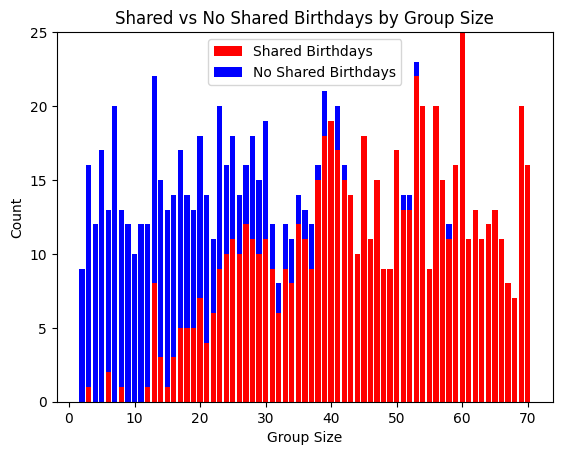

In [4]:
has_shared_birthday = df[df['shared_birthday'] == 1]
no_shared_birthday = df[df['shared_birthday'] == 0]
shared_counts = has_shared_birthday.groupby('group_size').count()['shared_birthday'].sort_index()
no_shared_counts = no_shared_birthday.groupby('group_size').count()['shared_birthday'].sort_index()

combined = pd.concat(
    [shared_counts, no_shared_counts],
    axis=1,
    keys=['shared', 'no_shared']
).fillna(0).sort_index()

plt.bar(combined.index, combined['shared'], color='red', label='Shared Birthdays')
plt.bar(combined.index, combined['no_shared'], color='blue', label='No Shared Birthdays', bottom=combined['shared'])
plt.xlabel('Group Size')
plt.ylabel('Count')
plt.title('Shared vs No Shared Birthdays by Group Size')
plt.legend()
plt.show()


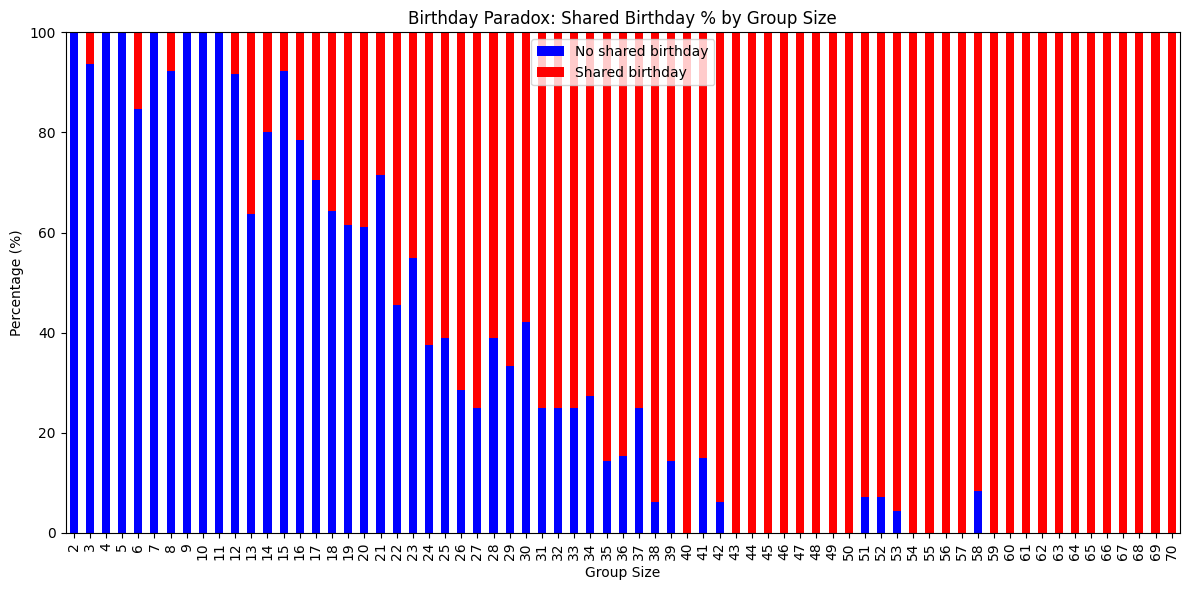

In [12]:
# Group the dataframe by both group_size and shared_birthday simultaneously,
# then count how many trials fall into each combination (e.g., group_size=23 with shared_birthday=1).
# .unstack() pivots shared_birthday (0 and 1) into separate columns so each row is one group_size.
# fill_value=0 replaces any missing combinations with 0 instead of NaN.
counts = df.groupby(['group_size', 'shared_birthday']).size().unstack(fill_value=0)

# Convert raw counts to percentages so we can compare group sizes fairly.
# counts.sum(axis=1) gives the total number of trials per group_size (across both columns).
# .div(..., axis=0) divides each row by its own total, giving a proportion (0.0–1.0).
# Multiplying by 100 converts to a percentage (0–100).
pct = counts.div(counts.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))

# Plot the "no shared birthday" percentage (column 0) as the bottom (base) of each bar.
pct[0].plot(kind='bar', ax=ax, label='No shared birthday', color='blue')

# Plot the "shared birthday" percentage (column 1) stacked on top of the previous bars.
# bottom=pct[0] tells matplotlib to start each bar where the blue bar left off,
# so the two segments always add up to 100% visually.
pct[1].plot(kind='bar', ax=ax, bottom=pct[0], label='Shared birthday', color='red')

ax.set_xlabel('Group Size')
ax.set_ylabel('Percentage (%)')
ax.set_title('Birthday Paradox: Shared Birthday % by Group Size')
ax.legend()
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()